In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv')

In [4]:
df.sample(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3892,3893,0,Graduate,No,9100000,27100000,12,787,24300000,2900000,34800000,9500000,Approved
1237,1238,2,Not Graduate,Yes,9500000,37500000,4,456,10200000,16800000,34100000,12900000,Approved
959,960,1,Graduate,Yes,9600000,34500000,2,795,9500000,900000,32000000,9300000,Approved
2611,2612,3,Not Graduate,Yes,4800000,14200000,12,369,3200000,200000,14000000,3000000,Rejected
1091,1092,4,Not Graduate,Yes,600000,2100000,6,558,1300000,1000000,2200000,300000,Approved
347,348,1,Not Graduate,No,7100000,23500000,12,768,6400000,12100000,22400000,7300000,Approved
1035,1036,2,Not Graduate,Yes,3800000,12500000,14,842,3700000,6700000,14600000,5300000,Approved
1365,1366,4,Not Graduate,No,7600000,29900000,18,445,4800000,13900000,18400000,5700000,Rejected
2519,2520,1,Not Graduate,Yes,1100000,2700000,16,346,1900000,300000,2200000,800000,Rejected
2213,2214,0,Graduate,No,3000000,8100000,6,683,3200000,4900000,10200000,3200000,Approved


In [5]:
df = df.drop(columns=['loan_id'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
# List all column names with quotes to see spaces
for col in df.columns:
    print(f"'{col}'")

' no_of_dependents'
' education'
' self_employed'
' income_annum'
' loan_amount'
' loan_term'
' cibil_score'
' residential_assets_value'
' commercial_assets_value'
' luxury_assets_value'
' bank_asset_value'
' loan_status'


In [7]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

# Verify the fix
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')


In [8]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


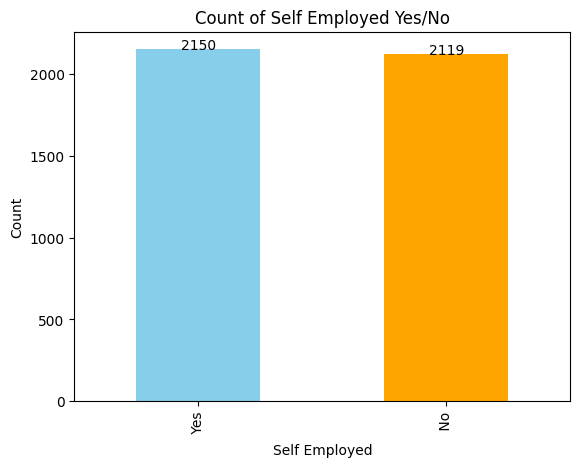

In [9]:
import matplotlib.pyplot as plt

# Bar plot
ax = df['self_employed'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.xlabel('Self Employed')
plt.ylabel('Count')
plt.title('Count of Self Employed Yes/No')

# Add count labels on top of bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,  # x position: center of the bar
        p.get_height() + 0.1,           # y position: a little above the bar
        int(p.get_height()),             # label: the height (count)
        ha='center'                      # horizontal alignment
    )

plt.show()

In [10]:
df['self_employed'] = df['self_employed'].str.strip()

# Mapping dictionary
mapping_self_employed = {"Yes": 1, "No": 0}

# Convert the column
df['self_employed'] = df['self_employed'].map(mapping_self_employed)

# Verify
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


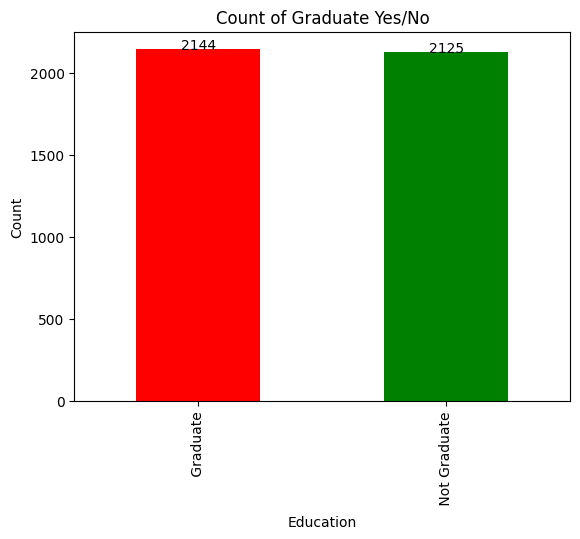

In [11]:
import matplotlib.pyplot as plt

# Bar plot
ax = df['education'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Count of Graduate Yes/No')

# Add count labels on top of bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,  # x position: center of the bar
        p.get_height() + 0.1,           # y position: a little above the bar
        int(p.get_height()),             # label: the height (count)
        ha='center'                      # horizontal alignment
    )

plt.show()

In [12]:
df['education'] = df['education'].str.strip()

# Mapping dictionary
mapping_self_employed = {"Graduate": 1, "Not Graduate": 0}

# Convert the column
df['education'] = df['education'].map(mapping_self_employed)

# Verify
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [13]:
df['loan_status'] = df['loan_status'].str.strip()

# Mapping dictionary
mapping_self_employed = {"Approved": 1, "Rejected": 0}

# Convert the column
df['loan_status'] = df['loan_status'].map(mapping_self_employed)

# Verify
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [14]:
# Strip spaces from all string/object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Verify
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


## Let's the Game Begin

In [15]:
df['loan_status'].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [16]:
# initial prediction
# log(# no of 1 / # no of 0)

df['pre1(log-odds)'] = np.log(2656/1613)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds)
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0.498725
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0.498725
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0.498725
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0.498725
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0.498725


In [17]:
# convert log odds to probability
df['pre1(probability)'] = 1/(1+np.exp(-np.log(2656/1613)))
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability)
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0.498725,0.62216
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0.498725,0.62216
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0.498725,0.62216
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0.498725,0.62216
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0.498725,0.62216


In [18]:
# calculating residual for stage 1
df['res1'] = df['loan_status'] - df['pre1(probability)']
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability),res1
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0.498725,0.62216,0.37784
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0.498725,0.62216,-0.62216
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0.498725,0.62216,-0.62216
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0.498725,0.62216,-0.62216
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0.498725,0.62216,-0.62216


In [19]:
from sklearn.metrics import accuracy_score

y_true = df['loan_status'] 

# Convert probabilities to 0/1 using threshold 0.5
y_pred = np.where(df['pre1(probability)'] >= 0.5, 1, 0)

# Calculate accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.622159756383228


In [20]:
X = df.iloc[:, 0:11]
y = df.iloc[:,-1].values
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [21]:
# training the first decision tree
from sklearn.tree import DecisionTreeRegressor

DTree1 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

DTree1.fit(X, y)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

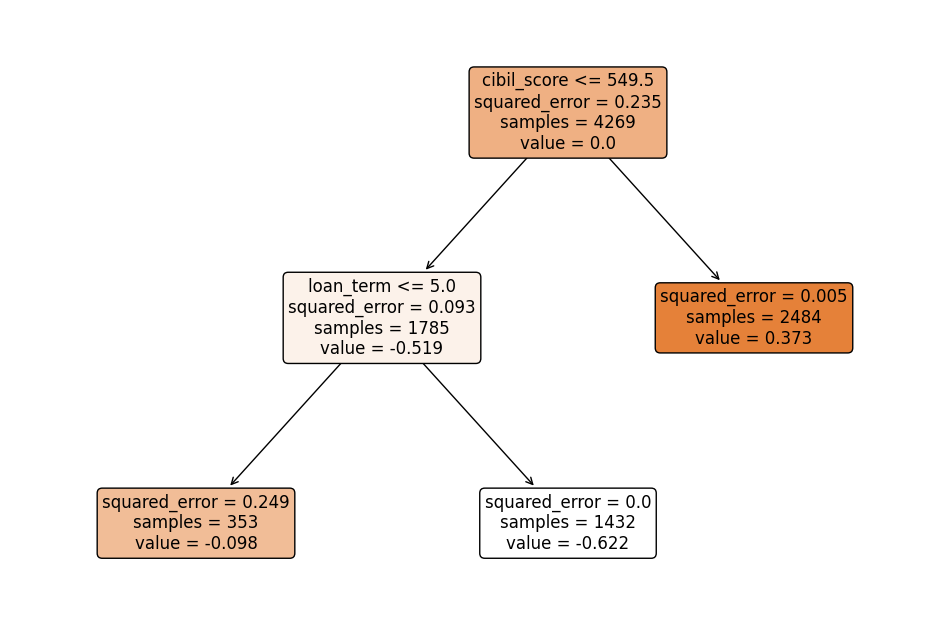

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(DTree1, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.show()

In [23]:
df['leaf_entry1'] = DTree1.apply(df.iloc[:,0:11])
df.sample(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability),res1,leaf_entry1
743,5,1,1,5800000,16600000,18,376,2500000,7500000,21100000,2800000,0,0.498725,0.62216,-0.62216,4
705,1,0,0,2800000,6700000,12,322,1900000,2000000,8600000,2100000,0,0.498725,0.62216,-0.62216,4
1579,5,1,0,1800000,6800000,18,457,2200000,1100000,3800000,1400000,0,0.498725,0.62216,-0.62216,4
2286,4,1,0,7100000,27200000,16,824,2400000,8000000,22400000,3900000,1,0.498725,0.62216,0.37784,2
3037,4,0,1,8700000,28200000,12,548,11800000,9900000,19800000,8500000,0,0.498725,0.62216,-0.62216,4


In [24]:
def return_logs(leaf):
  temp_df = df[df['leaf_entry1'] == leaf]
  num = temp_df['res1'].sum()

  den = sum(temp_df['pre1(probability)'] * (1 - temp_df['pre1(probability)']))
  return round(num/den,2)

In [25]:
df['pre2(log-odds)'] = df['pre1(log-odds)'] + df['leaf_entry1'].apply(return_logs)

In [26]:
df['pre2(probability)'] = 1/(1+np.exp(-df['pre2(log-odds)']))
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability)
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0.498725,0.62216,0.37784,2,2.088725,0.889803
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212


In [27]:
df['res2'] = df['loan_status'] - df['pre2(probability)']
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0.498725,0.62216,0.37784,2,2.088725,0.889803,0.110197
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212


In [28]:
from sklearn.metrics import accuracy_score

y_true = df['loan_status'] 

# Convert probabilities to 0/1 using threshold 0.5
y_pred2 = np.where(df['pre2(probability)'] >= 0.5, 1, 0)

# Calculate accuracy
acc = accuracy_score(y_true, y_pred2)
print("Accuracy:", acc)

Accuracy: 0.9576013117826189


In [29]:
# training the second decision tree
from sklearn.tree import DecisionTreeRegressor

DTree2 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

DTree2.fit(X, y)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

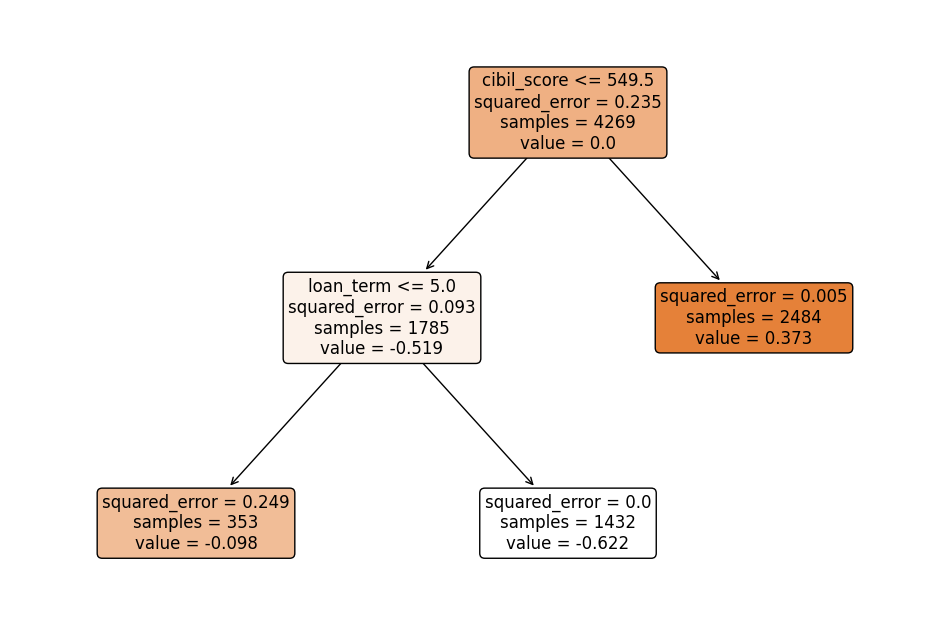

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(DTree2, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.show()

In [31]:
df['leaf_entry2'] = DTree2.apply(df.iloc[:,0:11])
df.sample(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2
1152,0,0,1,9400000,34200000,10,512,13100000,15600000,32600000,6300000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4
2765,2,0,0,2700000,6700000,8,413,7600000,800000,9200000,2300000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4
1708,1,0,1,2400000,9300000,20,543,700000,800000,5000000,3400000,0,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4
1616,5,0,1,9700000,25900000,2,754,9000000,10000000,28500000,6700000,1,0.498725,0.62216,0.37784,2,2.088725,0.889803,0.110197,2
1374,4,0,1,5300000,10700000,12,700,15800000,1900000,20500000,2900000,1,0.498725,0.62216,0.37784,2,2.088725,0.889803,0.110197,2


In [32]:
def return_logs(leaf):
  temp_df = df[df['leaf_entry2'] == leaf]
  num = temp_df['res2'].sum()

  den = sum(temp_df['pre2(probability)'] * (1 - temp_df['pre2(probability)']))
  return round(num/den,2)

In [33]:
df['pre3(log-odds)'] = df['pre2(log-odds)'] + df['leaf_entry2'].apply(return_logs)

In [34]:
df['pre3(probability)'] = 1/(1+np.exp(-df['pre3(log-odds)']))
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability)
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,...,0.498725,0.62216,0.37784,2,2.088725,0.889803,0.110197,2,3.158725,0.959251
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,...,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,...,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,...,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,...,0.498725,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570


In [35]:
df['res3'] = df['loan_status'] - df['pre3(probability)']
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability),res3
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,...,0.62216,0.37784,2,2.088725,0.889803,0.110197,2,3.158725,0.959251,0.040749
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,...,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570,-0.036570
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,...,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570,-0.036570
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,...,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570,-0.036570
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,...,0.62216,-0.62216,4,-2.151275,0.104212,-0.104212,4,-3.271275,0.036570,-0.036570


In [36]:
from sklearn.metrics import accuracy_score

y_true = df['loan_status'] 

# Convert probabilities to 0/1 using threshold 0.5
y_pred3 = np.where(df['pre3(probability)'] >= 0.5, 1, 0)

# Calculate accuracy
acc = accuracy_score(y_true, y_pred3)
print("Accuracy:", acc)

Accuracy: 0.9576013117826189


In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
import numpy as np

num_iterations = 30  # number of boosting-like iterations

# Initialize log-odds for the first iteration
df['pre0(log-odds)'] = np.log(2656/1613)
df['pre0(probability)'] = 1 / (1 + np.exp(-df['pre0(log-odds)']))

for i in range(1, num_iterations + 1):
    # Calculate residuals
    df[f'res{i}'] = df['loan_status'] - df[f'pre{i-1}(probability)']
    
    # Fit decision tree on residuals
    tree = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)
    tree.fit(df.iloc[:, 0:11], df[f'res{i}'])
    
    # Assign leaf node entries
    df[f'leaf_entry{i}'] = tree.apply(df.iloc[:, 0:11])
    
    # Function to compute log-odds adjustment per leaf
    def return_logs(leaf):
        temp_df = df[df[f'leaf_entry{i}'] == leaf]
        num = temp_df[f'res{i}'].sum()
        den = sum(temp_df[f'pre{i-1}(probability)'] * (1 - temp_df[f'pre{i-1}(probability)']))
        return round(num/den, 2)
    
    # Apply log-odds adjustment
    df[f'pre{i}(log-odds)'] = df[f'pre{i-1}(log-odds)'] + df[f'leaf_entry{i}'].apply(return_logs)
    
    # Update probabilities
    df[f'pre{i}(probability)'] = 1 / (1 + np.exp(-df[f'pre{i}(log-odds)']))
    
    # Calculate accuracy
    y_true = df['loan_status']
    y_pred = np.where(df[f'pre{i}(probability)'] >= 0.5, 1, 0)
    acc = accuracy_score(y_true, y_pred)
    
    print(f"Iteration {i} - Accuracy: {acc}")

Iteration 1 - Accuracy: 0.9576013117826189
Iteration 2 - Accuracy: 0.9576013117826189
Iteration 3 - Accuracy: 0.964394471773249
Iteration 4 - Accuracy: 0.9667369407355353
Iteration 5 - Accuracy: 0.9667369407355353
Iteration 6 - Accuracy: 0.9667369407355353
Iteration 7 - Accuracy: 0.9672054345279925
Iteration 8 - Accuracy: 0.9672054345279925
Iteration 9 - Accuracy: 0.9749355821035371
Iteration 10 - Accuracy: 0.9723588662450222
Iteration 11 - Accuracy: 0.9796205200281096
Iteration 12 - Accuracy: 0.9805575076130242
Iteration 13 - Accuracy: 0.98126024830171
Iteration 14 - Accuracy: 0.98126024830171
Iteration 15 - Accuracy: 0.9828999765753104
Iteration 16 - Accuracy: 0.9836027172639963
Iteration 17 - Accuracy: 0.9836027172639963
Iteration 18 - Accuracy: 0.9871164207074257
Iteration 19 - Accuracy: 0.986882173811197
Iteration 20 - Accuracy: 0.9864136800187397
Iteration 21 - Accuracy: 0.9875849144998828
Iteration 22 - Accuracy: 0.9880534082923401
Iteration 23 - Accuracy: 0.9880534082923401
Ite